In [218]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [219]:
df = pd.read_csv('HousingData.csv')

In [220]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [221]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [222]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [223]:
df.shape

(506, 14)

In [224]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [225]:
df['AGE'].isna().sum()

np.int64(0)

In [226]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [227]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [228]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [229]:
df.shape

(506, 14)

In [230]:
df.duplicated().sum()

np.int64(0)

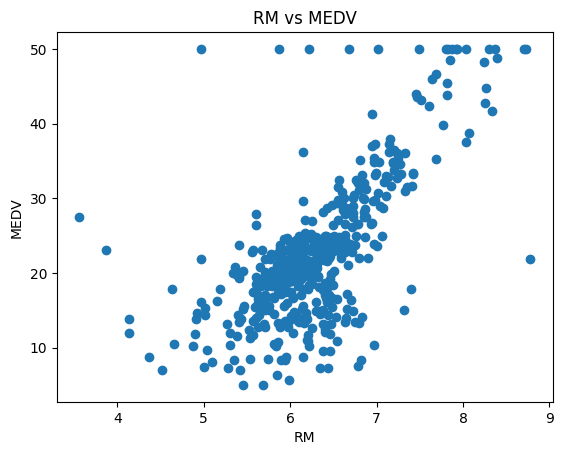

In [231]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [232]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [233]:
model = SVR(kernel='linear')
model.fit(X_train, y_train)

SVR(kernel='linear')

In [234]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [26.70440455 32.88099988 15.15897522 23.76823523 18.00570767 21.18259756
 18.47222734 16.51293431 18.74163915 20.20565468 21.76100176 18.79244066
 -6.44425498 20.90936037 17.6462462  24.26630805 18.97416242  5.21468788
 40.54535102 16.63451886 25.06362883 28.85973153 12.67684891 23.82276105
 15.81340113 11.75972655 19.96273004 13.94077625 20.1442603  18.84119782
 19.50610653 24.36193716 24.99783551 14.29057943 14.40806829 17.71223539
 30.34740155 19.97654161 21.89931012 22.78635766 14.51181298 30.08911992
 42.49901297 17.09043777 25.84409158 14.68822301 14.10721885 25.52053161
 17.67976595 28.87131956 20.3790333  31.37823547 17.18279264 25.58563833
 38.21947318 20.40324838 17.86652091 31.93175305 24.47904727 13.29104165
 23.96039976 32.1649172  29.24909029 15.75703656 22.31560245 14.18824682
 19.17882255 25.15300918 30.31749882 10.06361666 20.32710142 23.46323787
 10.81257765 13.79393799 22.11451778  6.44151061 20.24323651 41.13428457
 18.09153616  9.57966646 20.1536213  11.

In [235]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 3.131744451064659
R2 Score 0.5872699958716913


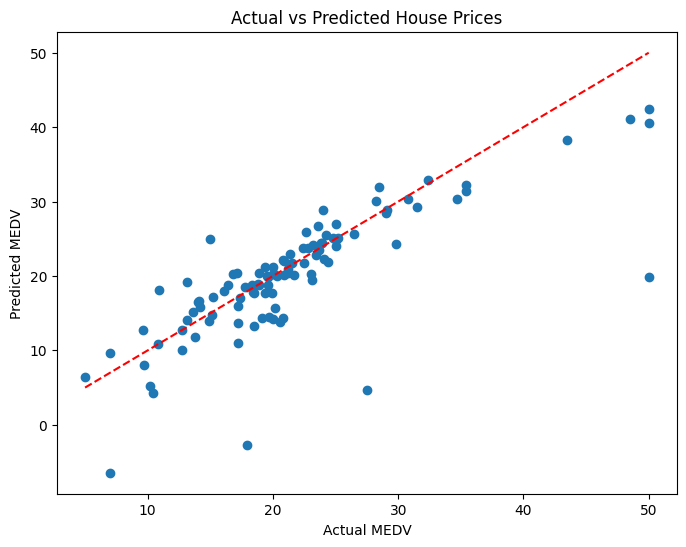

In [236]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [237]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [238]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([21.77943638])

In [239]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result['Difference'] = result['Actual'] - result['Predicted']

print(result.head(20))

     Actual  Predicted  Difference
173    23.6  26.704405   -3.104405
274    32.4  32.881000   -0.481000
491    13.6  15.158975   -1.558975
72     22.8  23.768235   -0.968235
452    16.1  18.005708   -1.905708
76     20.0  21.182598   -1.182598
316    17.8  18.472227   -0.672227
140    14.0  16.512934   -2.512934
471    19.6  18.741639    0.858361
500    16.8  20.205655   -3.405655
218    21.5  21.761002   -0.261002
9      18.9  18.792441    0.107559
414     7.0  -6.444255   13.444255
78     21.2  20.909360    0.290640
323    18.5  17.646246    0.853754
473    29.8  24.266308    5.533692
124    18.8  18.974162   -0.174162
388    10.2   5.214688    4.985312
195    50.0  40.545351    9.454649
448    14.1  16.634519   -2.534519


In [240]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.7074824243264617
Test R2: 0.5872699958716913


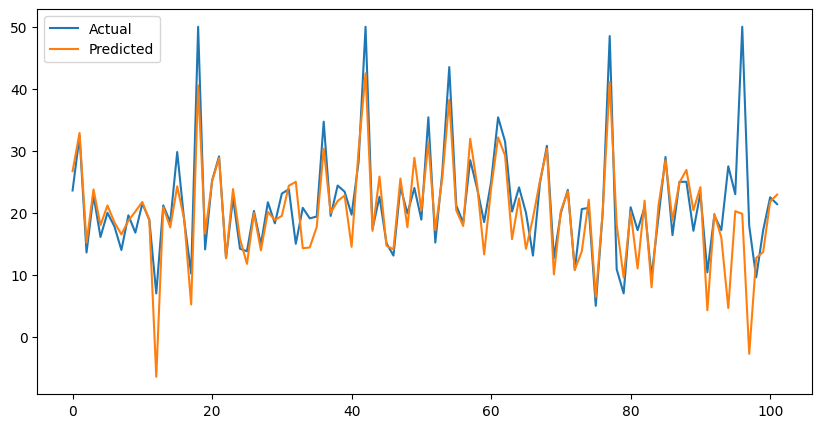

In [241]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.show()